# Numerical Optimization With Python

*Contributors: Dr Yae GABA; Dr Aurelle TCHAGNA; Mr. Domini LEKO*

# Well-conditioned vs Ill-conditioned Matrices (Practical Demo)

This notebook is designed for a **Numerical Optimization** course introduction.

We will see, with practical demos, why conditioning matters:

- **Well-conditioned**: small measurement noise → small error in the solution  
- **Ill-conditioned**: tiny noise → huge error (unstable / unreliable)

We include two demos:
1. **Solving** a linear system  \(Ax=b\) 
2. **Linear regression** with **highly correlated features** (common in ML), and how **Ridge** improves stability


In [ ]:
## 0. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


## 1. The concept (simple)

We often solve:
\[
Ax = b
\]

- **\(A\)**: how measurements (or tests/sensors) mix the true quantities  
- **\(b\)**: observed measurements (always a bit noisy in real life)  
- **\(x\)**: the true quantities we want (skills, parameters, signals, etc.)

### Conditioning (intuition)
- A matrix is **well-conditioned** if **small changes** in \(A\) or \(b\) lead to **small changes** in the solution \(x\).
- A matrix is **ill-conditioned** if **tiny changes** cause **big changes** in \(x\).

A common numerical indicator is the **condition number**:
\[
\kappa(A) = \|A\| \cdot \|A^{-1}\|
\]
In practice: `np.linalg.cond(A)`.

**Rule of thumb**
- \(\kappa(A)\) close to **1** → very stable  
- \(\kappa(A)\) very large → unstable, sensitive to noise


## 2. Two matrices: one good, one bad

Think of **two exams** measuring two underlying skills:
- Skill 1 = Math / Linear Algebra
- Skill 2 = Programming

**Well-conditioned**: the exams measure different things  
**Ill-conditioned**: the exams measure almost the same thing (redundant)


In [2]:
A_good = np.array([[1.0, 0.2],
                   [0.2, 1.0]])

A_bad  = np.array([[1.0, 0.99],
                   [0.99, 1.0]])

print("A_good =\n", A_good)
print("Condition number kappa(A_good):", np.linalg.cond(A_good))
print()
print("A_bad  =\n", A_bad)
print("Condition number kappa(A_bad): ", np.linalg.cond(A_bad))


A_good =
 [[1.  0.2]
 [0.2 1. ]]
Condition number kappa(A_good): 1.5000000000000007

A_bad  =
 [[1.   0.99]
 [0.99 1.  ]]
Condition number kappa(A_bad):  199.0000000000022


## 3. Geometric intuition (visual)

A matrix \(A\) transforms a **circle** into an **ellipse**.

- **Well-conditioned**: ellipse not too stretched  
- **Ill-conditioned**: ellipse extremely stretched (almost flat)

The more stretched, the more sensitive the inverse problem becomes.


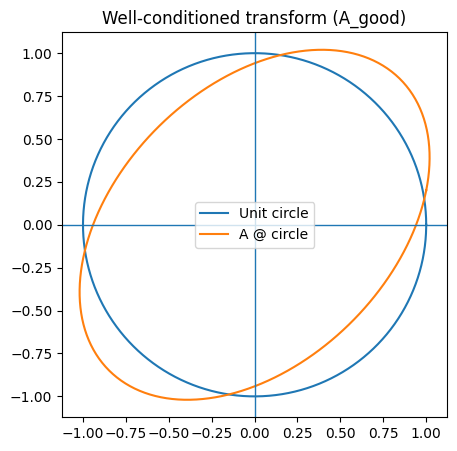

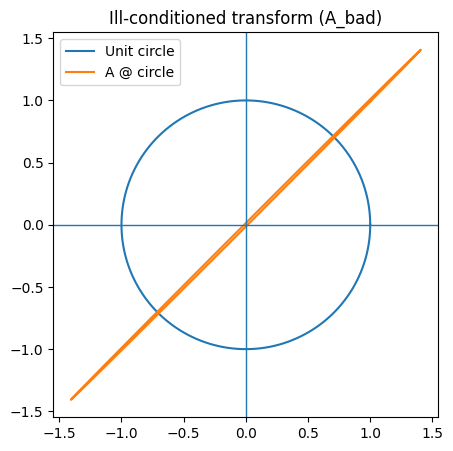

In [3]:
def plot_ellipse(A, title):
    t = np.linspace(0, 2*np.pi, 500)
    circle = np.vstack([np.cos(t), np.sin(t)])
    ellipse = A @ circle

    plt.figure(figsize=(5,5))
    plt.plot(circle[0], circle[1])
    plt.plot(ellipse[0], ellipse[1])
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.gca().set_aspect('equal', 'box')
    plt.title(title)
    plt.legend(["Unit circle", "A @ circle"])
    plt.show()

plot_ellipse(A_good, "Well-conditioned transform (A_good)")
plot_ellipse(A_bad,  "Ill-conditioned transform (A_bad)")


## 4. Practical demo 1 — Solving \(Ax=b\) with noise

### Story: estimating *true skills* from test results

Let the true skills be:
\[
x_{true} = [80, 60]^T
\]

Test results are:
\[
b = A x_{true}
\]

But in real life, measurements have **noise**:
\[
b_{noisy} = b + \epsilon
\]

We reconstruct:
\[
\hat{x} = A^{-1} b_{noisy}
\]


In [4]:
x_true = np.array([80.0, 60.0])

b_good = A_good @ x_true
b_bad  = A_bad  @ x_true

# Small noise (e.g., marking error or sensor noise)
noise = np.array([0.5, -0.5])

b_good_noisy = b_good + noise
b_bad_noisy  = b_bad  + noise

x_hat_good = np.linalg.solve(A_good, b_good_noisy)
x_hat_bad  = np.linalg.solve(A_bad,  b_bad_noisy)

print("True skills x_true:      ", x_true)
print("Recovered (A_good):      ", x_hat_good)
print("Recovered (A_bad):       ", x_hat_bad)
print()
print("Absolute error (A_good): ", np.abs(x_hat_good - x_true))
print("Absolute error (A_bad):  ", np.abs(x_hat_bad  - x_true))


True skills x_true:       [80. 60.]
Recovered (A_good):       [80.625 59.375]
Recovered (A_bad):        [130.  10.]

Absolute error (A_good):  [0.625 0.625]
Absolute error (A_bad):   [50. 50.]


## 5. Sensitivity experiment (repeat many times)

We repeat the same experiment 500 times with random tiny noise.
Watch how the error distribution becomes huge for the ill-conditioned case.


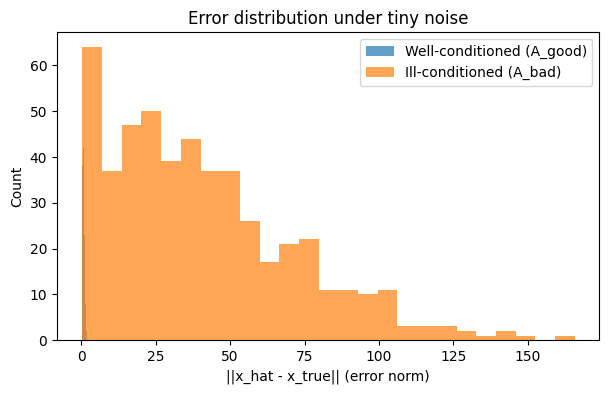

Mean error (good): 0.6322112976353778
Mean error (bad):  41.123231361153046


In [5]:
rng = np.random.default_rng(42)

def experiment(A, trials=500, noise_std=0.5):
    errors = []
    b = A @ x_true
    for _ in range(trials):
        eps = rng.normal(0, noise_std, size=2)
        x_hat = np.linalg.solve(A, b + eps)
        errors.append(np.linalg.norm(x_hat - x_true))
    return np.array(errors)

err_good = experiment(A_good, trials=500, noise_std=0.5)
err_bad  = experiment(A_bad,  trials=500, noise_std=0.5)

plt.figure(figsize=(7,4))
plt.hist(err_good, bins=25, alpha=0.7, label="Well-conditioned (A_good)")
plt.hist(err_bad,  bins=25, alpha=0.7, label="Ill-conditioned (A_bad)")
plt.xlabel("||x_hat - x_true|| (error norm)")
plt.ylabel("Count")
plt.title("Error distribution under tiny noise")
plt.legend()
plt.show()

print("Mean error (good):", err_good.mean())
print("Mean error (bad): ", err_bad.mean())


## 6. Real-world examples (where this shows up)

### (A) Machine Learning / Data Science
If two features are almost the same (highly correlated), the design matrix becomes ill-conditioned.
- Regression coefficients become unstable
- Small noise changes the model a lot

### (B) Medical sensing / imaging
If two sensors measure almost the same signal, reconstruction becomes unstable.
Small measurement noise can create large errors in estimated physiological variables.

### (C) Finance (portfolio optimization)
Highly correlated assets make the covariance matrix ill-conditioned.
Small estimation errors can lead to very different portfolio weights.


##  Key takeaway 

- The condition number measures **sensitivity** of solutions to small errors.
- Ill-conditioning is common in real data: correlated features, redundant sensors, covariance matrices, etc.
- In optimization and ML we handle it with:
  - feature scaling / normalization
  - PCA / feature selection
  - **regularization** (Ridge, weight decay)
  - **preconditioning** (for iterative solvers)

**Message:** good algorithms are not enough — the *numerical geometry* matters.
